# 1. Load VED and segment into microtrips

This notebook shows the smallest useful workflow: read one week of VED data, pick one trip, clean it, and split it into microtrips.

**Before running this notebook**, download VED from https://github.com/gsoh/VED (see `Data/` in that repository) and extract `VED_DynamicData_Part1.7z` and `Part2.7z`. Point `VED_CSV_PATH` below at one of the extracted `VED_mmddyy_week.csv` files.

In [1]:
VED_CSV_PATH = "VED_171101_week.csv"  # change to your extracted file

# A trip with plenty of stops, so the segmentation is visible.
# Set both to None to just take the first trip in the file.
PICK_VEHICLE = 434
PICK_TRIP = 512

In [2]:
from drivecycle_stats.io_ved import (
    clean_trip,
    iter_ved_trips,
    load_ved_dynamic_csv,
)
from drivecycle_stats.segment import segment_microtrips

raw = load_ved_dynamic_csv(VED_CSV_PATH)
print(f"{len(raw)} raw rows, {raw['VehId'].nunique()} vehicles")

489414 raw rows, 258 vehicles


Pick the first trip and clean it (resample to 1 Hz, clip acceleration).

In [3]:
from drivecycle_stats.io_ved import (
    load_ved_dynamic_csv,
)

raw = load_ved_dynamic_csv(VED_CSV_PATH)
print(f"{len(raw)} raw rows, {raw['VehId'].nunique()} vehicles")

veh_id = trip_id = raw_trip = None
for _v, _t, _rt in iter_ved_trips(raw):
    if PICK_VEHICLE is None or (_v == PICK_VEHICLE and _t == PICK_TRIP):
        veh_id, trip_id, raw_trip = _v, _t, _rt
        break
if raw_trip is None:
    raise SystemExit(f"trip {PICK_VEHICLE}/{PICK_TRIP} not in this weekly file")
print(f"VehId={veh_id} Trip={trip_id}")

frame, report = clean_trip(raw_trip)
report

489414 raw rows, 258 vehicles
VehId=434 Trip=512


{'n_raw_rows': 1230,
 'n_dropped_missing_speed': 0,
 'n_resampled_rows': 1097,
 'n_accel_clipped': 2,
 'dropped_reason': None}

Split into microtrips: a microtrip runs from one stop to the next.

In [4]:
microtrips, summary = segment_microtrips(frame, min_stop_duration_s=2)
print(f"{len(microtrips)} microtrips")
summary

23 microtrips


,start_idx,end_idx,n_seconds,distance_km
0,0,96,97,1.605797
1,97,157,61,0.601326
2,158,225,68,0.529282
3,226,342,117,1.109146
4,343,396,54,0.265497
5,397,451,55,0.778942
6,452,561,110,0.841849
7,562,619,58,0.436816
8,620,667,48,0.234528
9,668,747,80,0.473958


Plot the trip with microtrip boundaries marked.

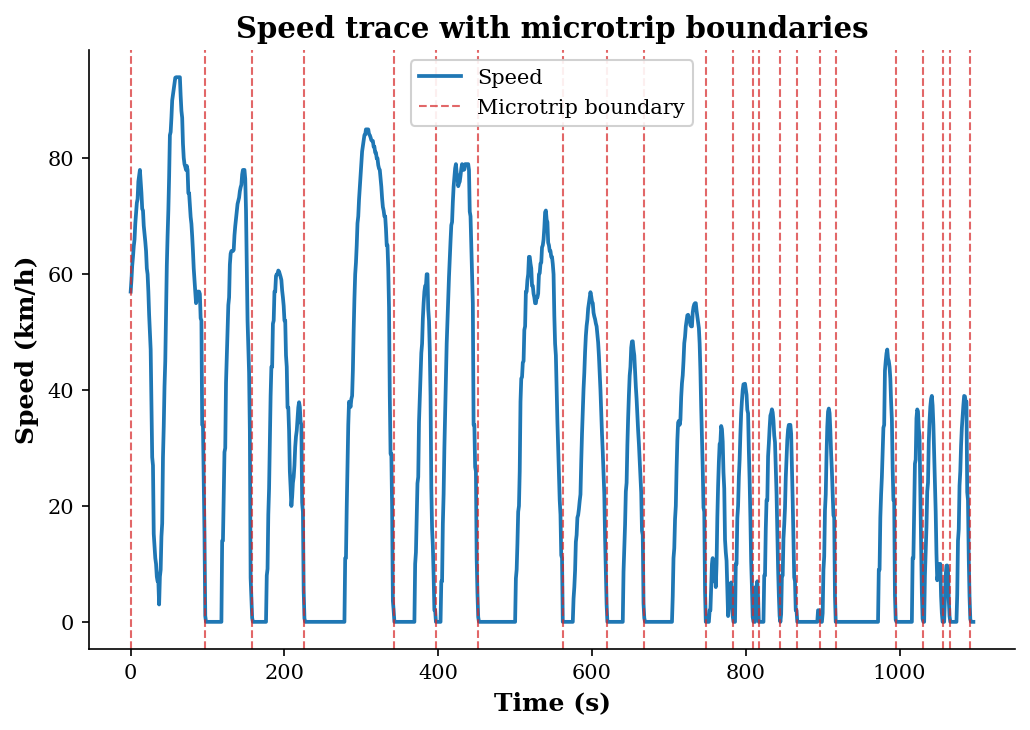

In [5]:
from drivecycle_stats.figures import plot_speed_trace_with_microtrips

fig = plot_speed_trace_with_microtrips(frame, summary)
fig.savefig("01_speed_trace.png", dpi=600, bbox_inches="tight")